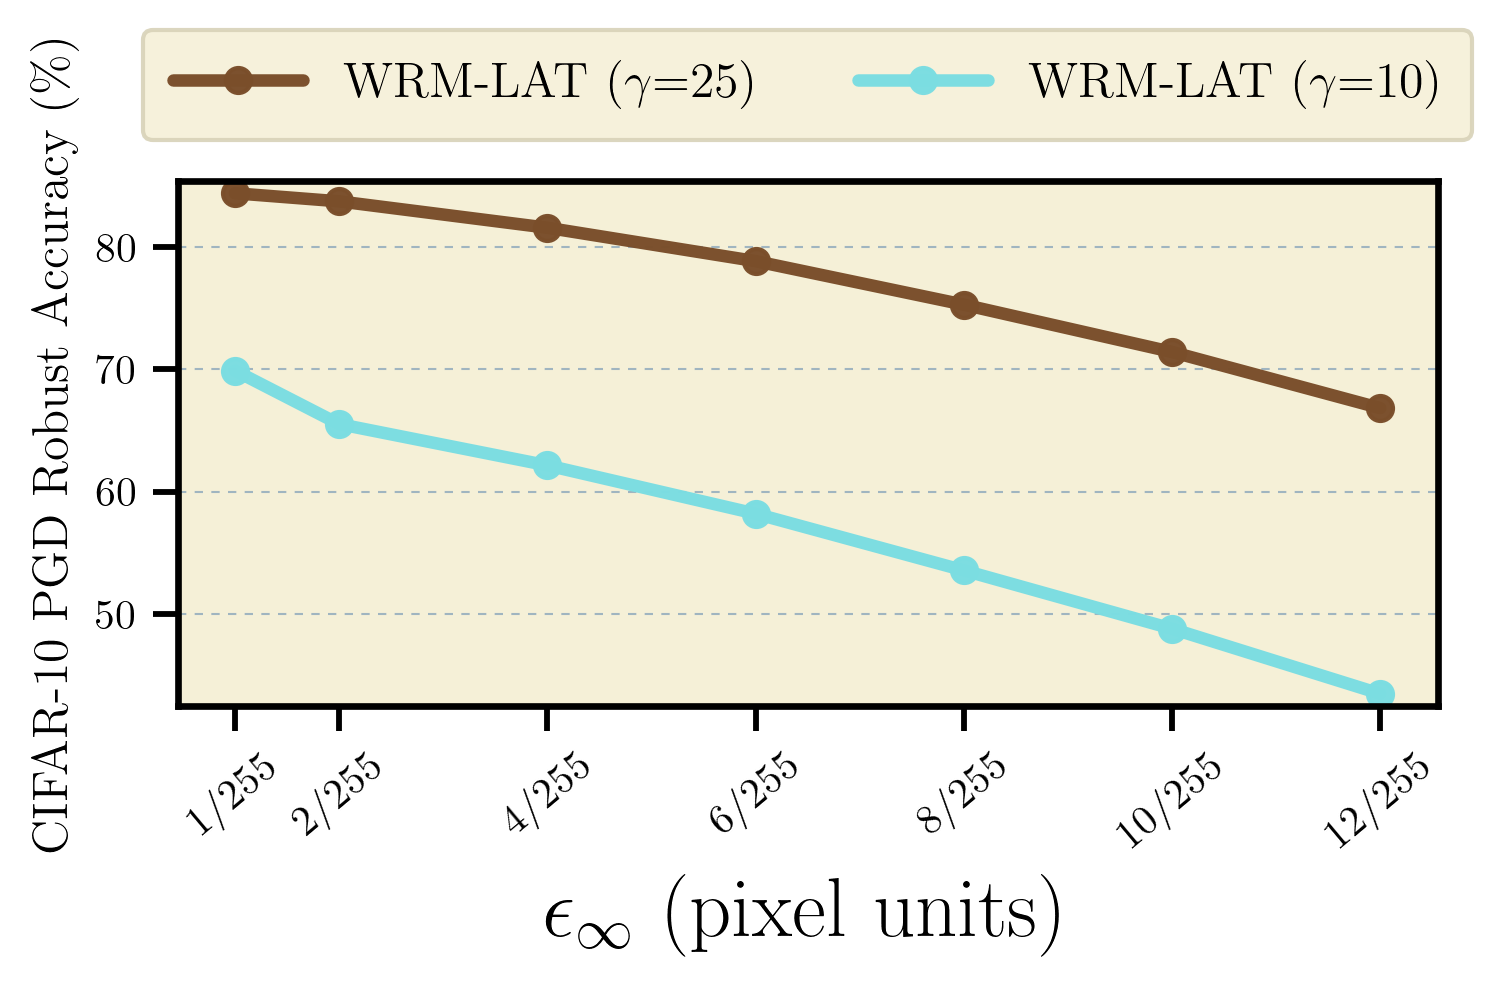

In [2]:
from pathlib import Path
import json
import numpy as np

from plot_template import set_paper_style, styled_axes, plot_series, add_legend

# Apply the shared plotting style
set_paper_style()

def load_model_metrics(json_paths, model_label):
    """Collect epsilon and robust accuracy pairs for a model."""
    records = []
    for path in json_paths:
        with open(path, "r") as f:
            data = json.load(f)

        scores = data.get("scores", {})
        pgd_params = scores.get("pgd_params", {})
        cifar10_pgd = scores.get("cifar10_pgd", {})
        eps = pgd_params.get("eps")
        robust_acc = cifar10_pgd.get("acc")

        if eps is None or robust_acc is None:
            continue

        records.append((float(eps), float(robust_acc), path.name))

    if not records:
        raise ValueError(f"No PGD metrics found for {model_label}.")

    records.sort(key=lambda item: item[0])
    eps_values = np.array([item[0] for item in records])
    robust_values = np.array([item[1] for item in records])
    source_files = [item[2] for item in records]
    return eps_values, robust_values, source_files


def harmonize_epsilons(eps_values, denominator=255):
    """Snap epsilon values to multiples of 1/denominator to avoid duplicate ticks."""
    return np.round(eps_values * denominator) / denominator


# Look for the evaluation JSON files in the current directory
base_dir = Path.cwd()
json_paths_model_a = sorted(base_dir.glob("cifar10_variants_eval_ckpt-R2-adv-gamma-025_*.json"))
json_paths_model_b = sorted(base_dir.glob("cifar10_variants_eval_ckpt-R2-adv-test_*.json"))

# Load metrics for both models
eps_a, robust_a, source_files_a = load_model_metrics(json_paths_model_a, "WRM-LAT (R2, gamma=0.25)")
eps_b, robust_b, source_files_b = load_model_metrics(json_paths_model_b, "WRM-LAT (R2, test)")

# Align epsilon values to the same discrete grid (e.g., 8/255 vs 0.03137255)
eps_a = harmonize_epsilons(eps_a)
eps_b = harmonize_epsilons(eps_b)

# Configure consistent tick locations across both series
xtick_eps = np.unique(np.concatenate([eps_a, eps_b]))
# print(xtick_eps)
robust_all = np.concatenate([robust_a, robust_b])

# Plot both models on the same axes
fig, ax = styled_axes()
ax.set_xlabel(r"$\epsilon_{\infty}$ (pixel units)")
ax.set_ylabel("CIFAR-10 PGD Robust Accuracy (\%)")
plot_series(ax, eps_a, robust_a, label="WRM-LAT ($\gamma$=25)", color_key="mars", marker="o")
plot_series(ax, eps_b, robust_b, label="WRM-LAT ($\gamma$=10)", color_key="signum", marker="o")
ax.set_xticks(xtick_eps)
ax.set_xticklabels([f"{int(round(eps * 255))}/255" for eps in xtick_eps], rotation=40)
ax.set_ylim(robust_all.min() - 1, max(robust_all.max() + 1, 5))
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(12)
add_legend(ax, loc="lower center", bbox_to_anchor=(0.5, 1.05), ncol=2, borderaxespad=0.3)
fig.subplots_adjust(top=0.7)

# save the figure
fig.savefig("cifar10_wrm_lat_robust_accuracy_comparison_R2_gamma_0.25_gamma_0.10.pdf", dpi=300, bbox_inches="tight")